# Exploratory Data Analysis: Loan Limit Optimization System

**Purpose**: Comprehensive analysis of loan limit increase data to inform demand forecasting and risk modeling.

**Context**: CredAble (Kenya) single-timepoint snapshot (Dec 31, 2023) of 30K customers. This EDA validates business assumptions and quantifies key parameters for:
- Cox Proportional Hazards demand model
- Markov transition matrix risk model
- Three-outcome profit model (Early/OnTime/Default)
- MILP optimization constraints

**Key Objectives**:
1. Validate data quality and business assumptions
2. Quantify acceptance rates and behavior patterns
3. Establish risk segmentation boundaries
4. Identify outliers and data limitations
5. Generate processed dataset for modeling

---

In [1]:
# Standard imports
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
sys.path.append(str(Path.cwd().parent))

# Project imports
from src.data_processing import load_raw_data, get_data_info
from config.constants import (
    PROFIT_ON_TIME,
    PROFIT_EARLY,
    DEFAULT_RECOVERY_RATE,
    LOSS_REALIZATION_PCT,
    DEFAULT_RISK_APPETITE,
    ANNUAL_REGULATORY_LIMIT
)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

# Random seed for reproducibility
np.random.seed(42)

## 1. Data Overview

Load data and assess dimensions, structure, quality.

In [2]:
# Load raw data
df = load_raw_data()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")

Dataset shape: 30,000 rows × 6 columns

Column names:
  - customer_id
  - initial_loan
  - days_since_last_loan
  - on-time_payments
  - no_of_increases_in_2023
  - total_profit_contribution


In [3]:
# First look at the data
df.head(10)

,customer_id,initial_loan,days_since_last_loan,on-time_payments,no_of_increases_in_2023,total_profit_contribution
0,1001,1360,72,90.41,5,120
1,1002,4272,54,90.32,0,0
2,1003,3592,242,85.56,4,80
3,1004,966,301,95.86,0,0
4,1005,4926,352,94.80,0,0
5,1006,3944,214,84.68,4,80
6,1007,3671,14,86.40,0,0
7,1008,3419,146,95.77,0,0
8,1009,630,143,87.15,0,0
9,1010,2185,24,88.07,3,40


In [4]:
# Data types and missing values
info = get_data_info(df)

quality_df = pd.DataFrame({
    'Data Type': info['dtypes'],
    'Missing Count': info['missing'],
    'Missing %': info['missing_pct']
})

print("Data Quality Summary:")
print(quality_df)
print(f"\nTotal missing values: {info['missing'].sum():,}")

Data Quality Summary:
                          Data Type  Missing Count  Missing %
customer_id                   int64              0        0.0
initial_loan                  int64              0        0.0
days_since_last_loan          int64              0        0.0
on-time_payments            float64              0        0.0
no_of_increases_in_2023       int64              0        0.0
total_profit_contribution     int64              0        0.0

Total missing values: 0


In [5]:
# Descriptive statistics
df.describe()

,customer_id,initial_loan,days_since_last_loan,on-time_payments,no_of_increases_in_2023,total_profit_contribution
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,16000.50,2752.53,181.48,90.02,2.24,44.72
std,8660.40,1293.03,105.07,5.75,2.08,46.63
min,1001.00,500.00,0.00,80.00,0.00,0.00
25%,8500.75,1630.00,90.00,85.08,0.00,0.00
50%,16000.50,2761.00,182.00,90.05,3.00,40.00
75%,23500.25,3866.00,272.00,95.01,4.00,80.00
max,31000.00,4999.00,364.00,100.00,5.00,120.00


**Key Observations (Section 1)**:
- Dataset dimensions and completeness
- Data types appropriate for modeling
- Missing value assessment

---
## 2. Univariate Analysis

Distribution analysis for all features.

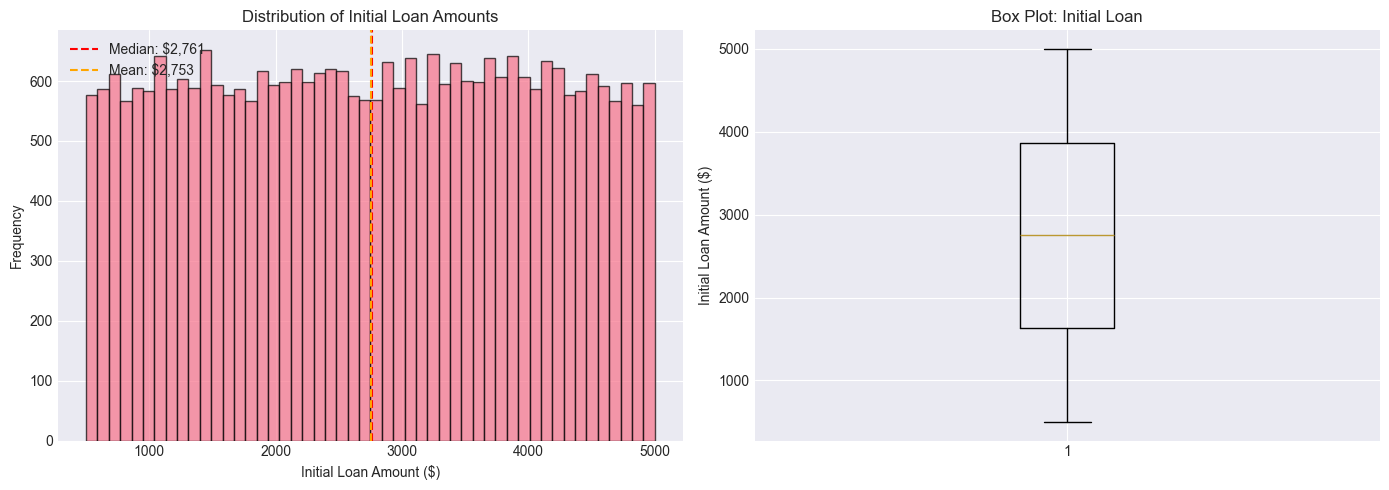

Initial_Loan Statistics:
  Mean: $2,752.53
  Median: $2,761.00
  Std Dev: $1,293.03
  Min: $500.00
  Max: $4,999.00


In [6]:
# Initial_Loan distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['initial_loan'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Initial Loan Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Initial Loan Amounts')
axes[0].axvline(df['initial_loan'].median(), color='red', linestyle='--', label=f"Median: ${df['initial_loan'].median():,.0f}")
axes[0].axvline(df['initial_loan'].mean(), color='orange', linestyle='--', label=f"Mean: ${df['initial_loan'].mean():,.0f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df['initial_loan'], vert=True)
axes[1].set_ylabel('Initial Loan Amount ($)')
axes[1].set_title('Box Plot: Initial Loan')

plt.tight_layout()
plt.savefig('../outputs/figures/initial_loan_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Initial_Loan Statistics:")
print(f"  Mean: ${df['initial_loan'].mean():,.2f}")
print(f"  Median: ${df['initial_loan'].median():,.2f}")
print(f"  Std Dev: ${df['initial_loan'].std():,.2f}")
print(f"  Min: ${df['initial_loan'].min():,.2f}")
print(f"  Max: ${df['initial_loan'].max():,.2f}")

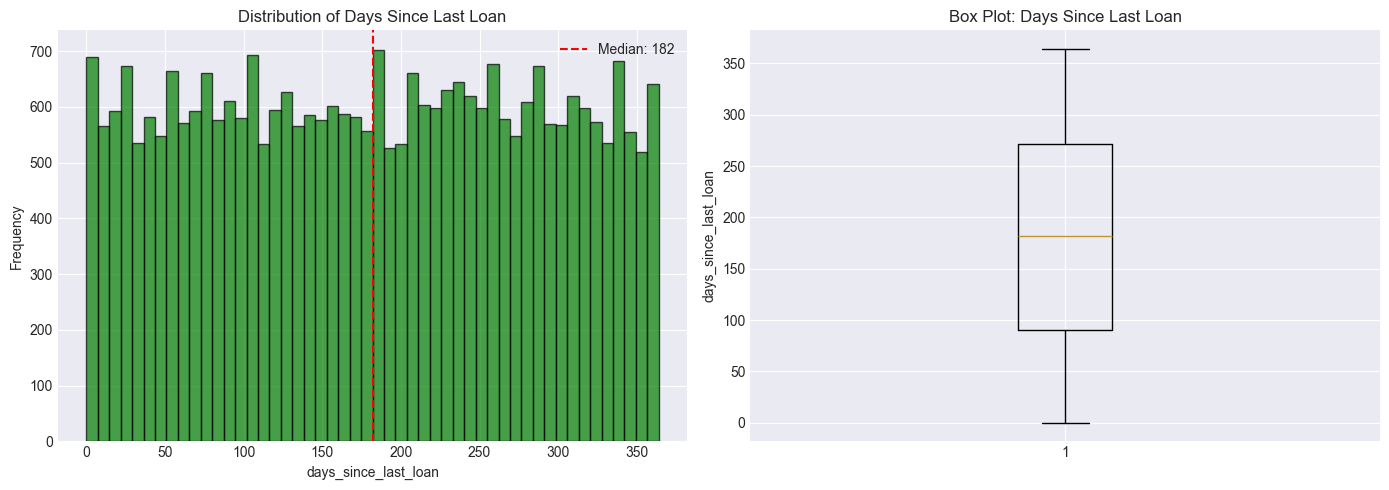

Days_Since_Last_Loan Statistics:
  Mean: 181.48
  Median: 182.00
  Max: 364 (validates Dec 31, 2023 snapshot)


In [7]:
# Days_Since_Last_Loan distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['days_since_last_loan'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('days_since_last_loan')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Days Since Last Loan')
axes[0].axvline(df['days_since_last_loan'].median(), color='red', linestyle='--', label=f"Median: {df['days_since_last_loan'].median():.0f}")
axes[0].legend()

axes[1].boxplot(df['days_since_last_loan'], vert=True)
axes[1].set_ylabel('days_since_last_loan')
axes[1].set_title('Box Plot: Days Since Last Loan')

plt.tight_layout()
plt.savefig('../outputs/figures/days_since_loan_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Days_Since_Last_Loan Statistics:")
print(f"  Mean: {df['days_since_last_loan'].mean():.2f}")
print(f"  Median: {df['days_since_last_loan'].median():.2f}")
print(f"  Max: {df['days_since_last_loan'].max():.0f} (validates Dec 31, 2023 snapshot)")

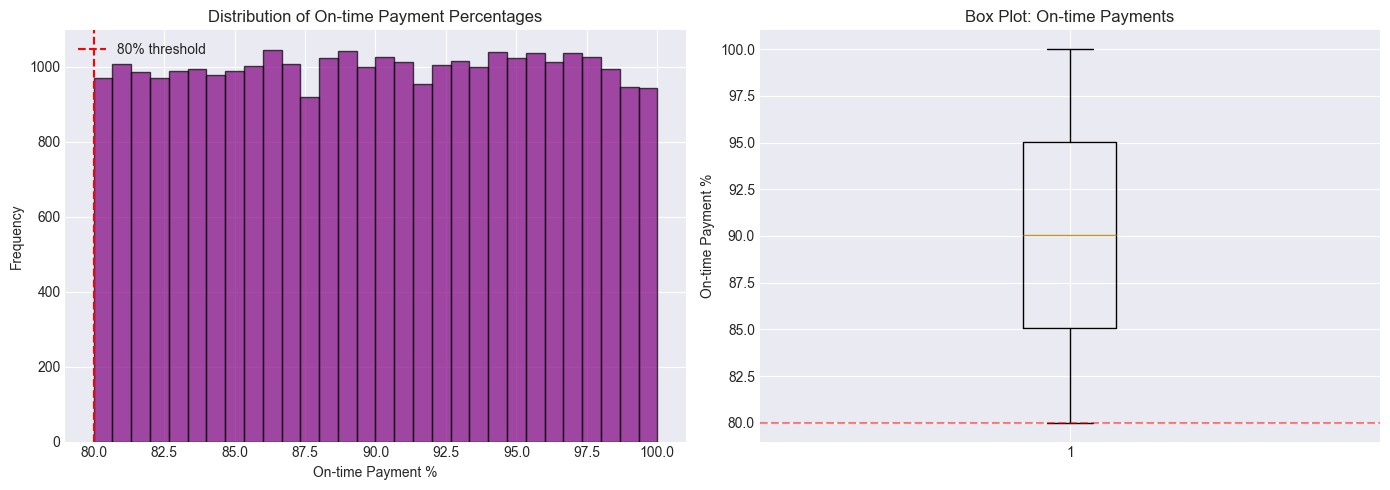

On-time_Payments Statistics:
  Mean: 90.02%
  Median: 90.05%
  Min: 80.00%
  % >= 80%: 100.00%


In [10]:
# On-time Payments Percentage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['on-time_payments'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_xlabel('On-time Payment %')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of On-time Payment Percentages')
axes[0].axvline(80, color='red', linestyle='--', label='80% threshold')
axes[0].legend()

axes[1].boxplot(df['on-time_payments'], vert=True)
axes[1].set_ylabel('On-time Payment %')
axes[1].set_title('Box Plot: On-time Payments')
axes[1].axhline(80, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/figures/ontime_payment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"On-time_Payments Statistics:")
print(f"  Mean: {df['on-time_payments'].mean():.2f}%")
print(f"  Median: {df['on-time_payments'].median():.2f}%")
print(f"  Min: {df['on-time_payments'].min():.2f}%")
print(f"  % >= 80%: {(df['on-time_payments'] >= 80).mean() * 100:.2f}%")

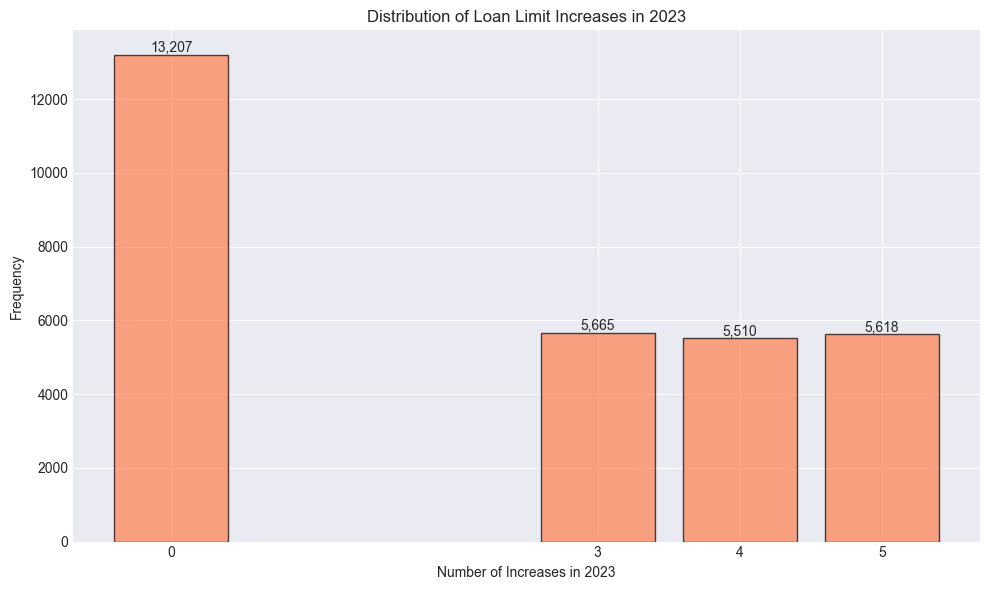

No_of_Increases_2023 Value Counts:
no_of_increases_in_2023
0    13207
3     5665
4     5510
5     5618
Name: count, dtype: int64

Unique values: [np.int64(0), np.int64(3), np.int64(4), np.int64(5)]

⚠️ CAC Model Check: Should only have 0, 3, 4, 5 (no 1 or 2)


In [11]:
# No_of_Increases_2023 distribution (CRITICAL for CAC model validation)
increase_counts = df['no_of_increases_in_2023'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(increase_counts.index, increase_counts.values, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Number of Increases in 2023')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Loan Limit Increases in 2023')
ax.set_xticks(increase_counts.index)

# Add value labels on bars
for i, v in zip(increase_counts.index, increase_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../outputs/figures/increases_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("No_of_Increases_2023 Value Counts:")
print(increase_counts)
print(f"\nUnique values: {sorted(df['no_of_increases_in_2023'].unique())}")
print(f"\n⚠️ CAC Model Check: Should only have 0, 3, 4, 5 (no 1 or 2)")

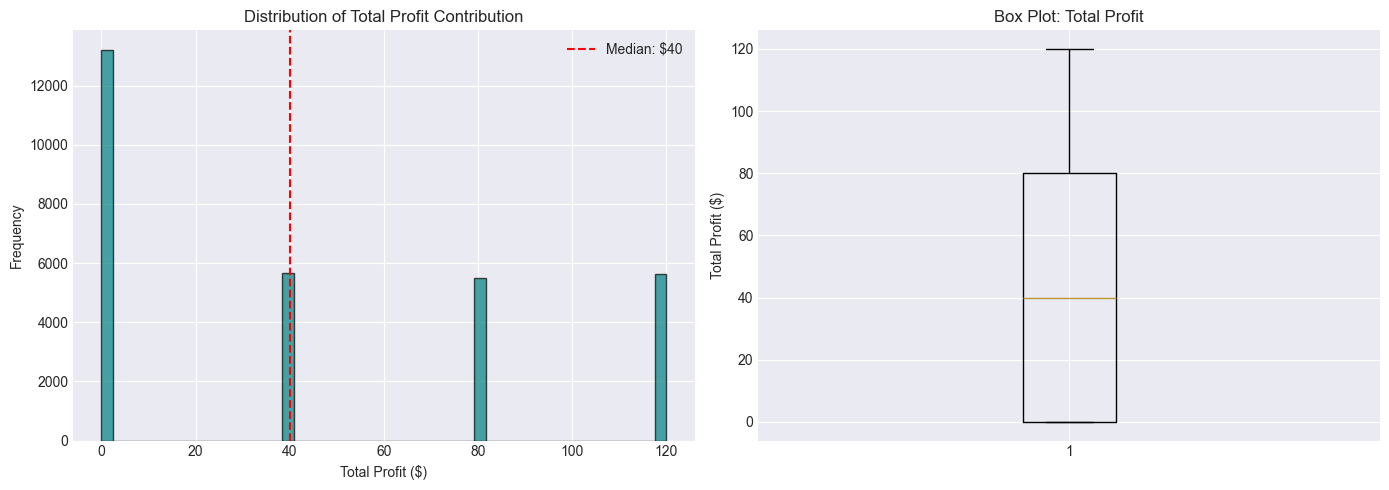

Total_Profit Statistics:
  Mean: $44.72
  Median: $40.00
  Total: $1,341,560.00


In [12]:
# Total_Profit_Contribution distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_profit_contribution'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_xlabel('Total Profit ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Profit Contribution')
axes[0].axvline(df['total_profit_contribution'].median(), color='red', linestyle='--', 
                label=f"Median: ${df['total_profit_contribution'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['total_profit_contribution'], vert=True)
axes[1].set_ylabel('Total Profit ($)')
axes[1].set_title('Box Plot: Total Profit')

plt.tight_layout()
plt.savefig('../outputs/figures/profit_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total_Profit Statistics:")
print(f"  Mean: ${df['total_profit_contribution'].mean():,.2f}")
print(f"  Median: ${df['total_profit_contribution'].median():,.2f}")
print(f"  Total: ${df['total_profit_contribution'].sum():,.2f}")

**Key Observations (Section 2)**:
- Feature distributions and central tendencies
- Validation of data ranges
- Identification of distribution shapes (normal, skewed, etc.)

---
## 3. Bivariate Analysis

Correlation and relationship analysis between features.

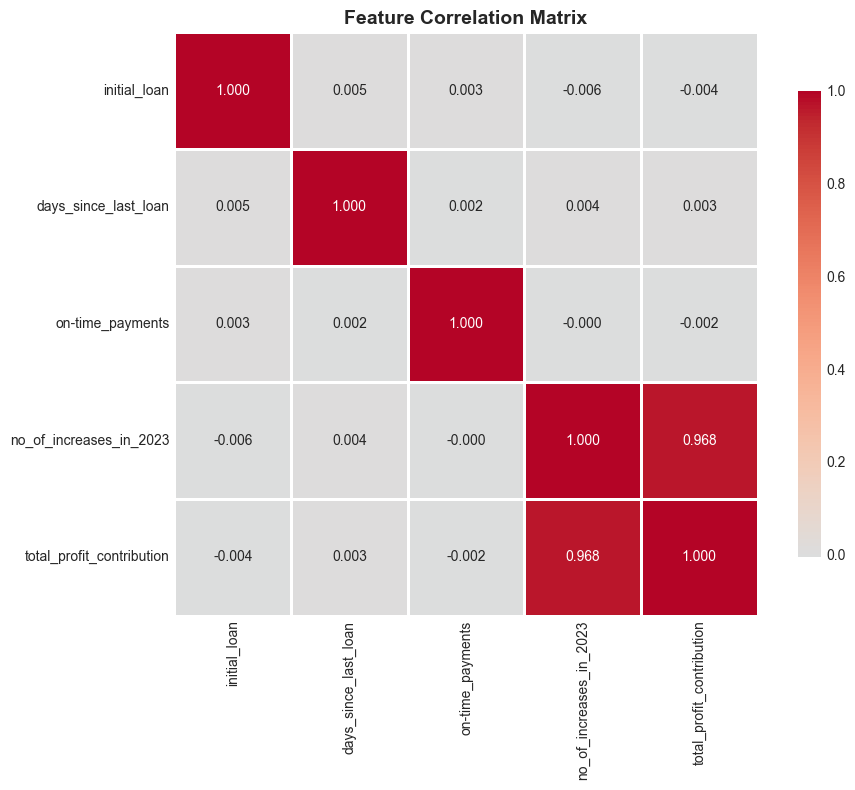

Correlation Matrix:
                           initial_loan  days_since_last_loan  \
initial_loan                   1.00e+00              5.21e-03   
days_since_last_loan           5.21e-03              1.00e+00   
on-time_payments               3.45e-03              1.90e-03   
no_of_increases_in_2023       -5.57e-03              3.61e-03   
total_profit_contribution     -4.22e-03              2.91e-03   

                           on-time_payments  no_of_increases_in_2023  \
initial_loan                       3.45e-03                -5.57e-03   
days_since_last_loan               1.90e-03                 3.61e-03   
on-time_payments                   1.00e+00                -1.41e-04   
no_of_increases_in_2023           -1.41e-04                 1.00e+00   
total_profit_contribution         -1.63e-03                 9.68e-01   

                           total_profit_contribution  
initial_loan                               -4.22e-03  
days_since_last_loan                        2.

In [14]:
# Correlation matrix
numeric_cols = ['initial_loan', 'days_since_last_loan', 'on-time_payments', 
                'no_of_increases_in_2023', 'total_profit_contribution']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation Matrix:")
print(corr_matrix)

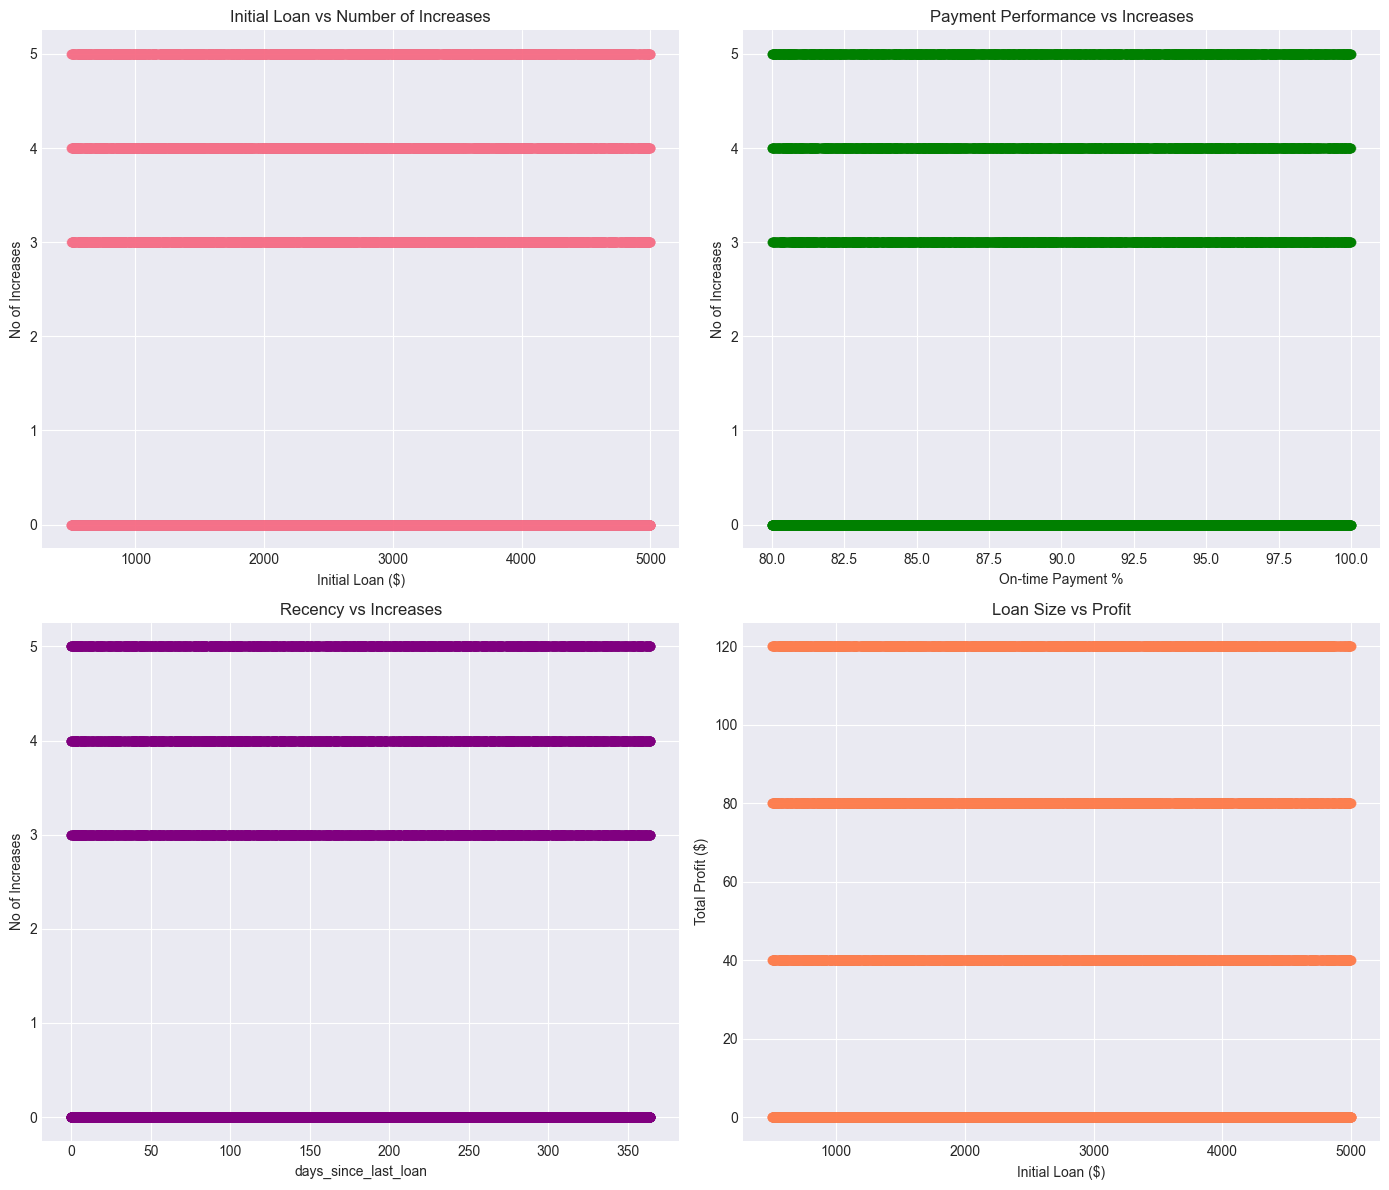

In [16]:
# Scatter plots: Key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Initial_Loan vs No_of_Increases
axes[0, 0].scatter(df['initial_loan'], df['no_of_increases_in_2023'], alpha=0.3)
axes[0, 0].set_xlabel('Initial Loan ($)')
axes[0, 0].set_ylabel('No of Increases')
axes[0, 0].set_title('Initial Loan vs Number of Increases')

# On-time % vs No_of_Increases
axes[0, 1].scatter(df['on-time_payments'], df['no_of_increases_in_2023'], alpha=0.3, color='green')
axes[0, 1].set_xlabel('On-time Payment %')
axes[0, 1].set_ylabel('No of Increases')
axes[0, 1].set_title('Payment Performance vs Increases')

# Days_Since vs No_of_Increases
axes[1, 0].scatter(df['days_since_last_loan'], df['no_of_increases_in_2023'], alpha=0.3, color='purple')
axes[1, 0].set_xlabel('days_since_last_loan')
axes[1, 0].set_ylabel('No of Increases')
axes[1, 0].set_title('Recency vs Increases')

# Initial_Loan vs Total_Profit
axes[1, 1].scatter(df['initial_loan'], df['total_profit_contribution'], alpha=0.3, color='coral')
axes[1, 1].set_xlabel('Initial Loan ($)')
axes[1, 1].set_ylabel('Total Profit ($)')
axes[1, 1].set_title('Loan Size vs Profit')

plt.tight_layout()
plt.savefig('../outputs/figures/bivariate_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

**Key Observations (Section 3)**:
- Correlation strengths and directions
- Linear vs non-linear relationships
- Predictive feature identification

---
## 4. Temporal Analysis

Validate 60-day rule and temporal patterns.

60-DAY ELIGIBILITY RULE VALIDATION

Maximum Days Since Last Loan: 364
Expected: 364 (Dec 31, 2023 - Jan 1, 2023 = 364 days)
Validation: ✓ PASS

Distribution by 60-day windows:
  0-60 days: 5,000 customers (16.7%)
  61-120 days: 5,028 customers (16.8%)
  121-180 days: 4,840 customers (16.1%)
  181-240 days: 4,971 customers (16.6%)
  241-300 days: 5,054 customers (16.8%)
  301-365 days: 5,107 customers (17.0%)


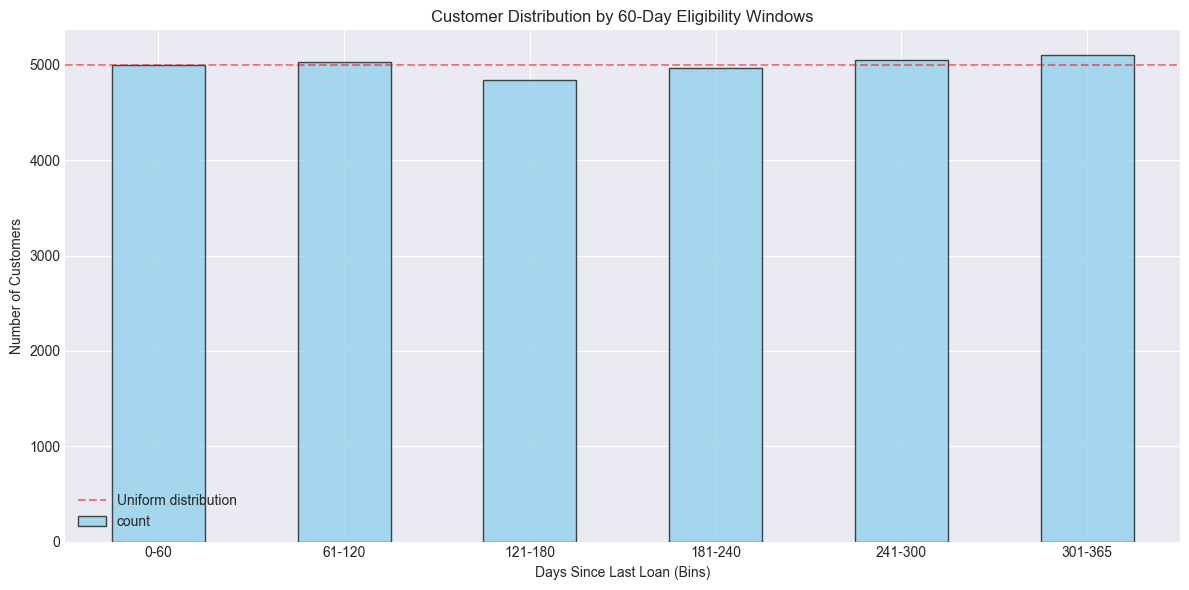

In [17]:
# 60-day rule validation
print("=" * 60)
print("60-DAY ELIGIBILITY RULE VALIDATION")
print("=" * 60)

# Maximum days since last loan
max_days = df['days_since_last_loan'].max()
print(f"\nMaximum Days Since Last Loan: {max_days}")
print(f"Expected: 364 (Dec 31, 2023 - Jan 1, 2023 = 364 days)")
print(f"Validation: {'✓ PASS' if max_days == 364 else '✗ FAIL'}")

# Distribution by eligibility windows
bins = [0, 60, 120, 180, 240, 300, 365]
labels = ['0-60', '61-120', '121-180', '181-240', '241-300', '301-365']
df['Days_Bin'] = pd.cut(df['days_since_last_loan'], bins=bins, labels=labels, include_lowest=True)

print("\nDistribution by 60-day windows:")
days_dist = df['Days_Bin'].value_counts().sort_index()
for window, count in days_dist.items():
    pct = count / len(df) * 100
    print(f"  {window} days: {count:,} customers ({pct:.1f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
days_dist.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Days Since Last Loan (Bins)')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Distribution by 60-Day Eligibility Windows')
ax.axhline(len(df) / len(labels), color='red', linestyle='--', alpha=0.5, label='Uniform distribution')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/temporal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Drop temporary column
df = df.drop('Days_Bin', axis=1)

In [18]:
# Relationship between recency and increases
avg_increases_by_recency = df.groupby(
    pd.cut(df['days_since_last_loan'], bins=12)
)['no_of_increases_in_2023'].mean()

print("\nAverage increases by recency (monthly bins):")
print(avg_increases_by_recency)


Average increases by recency (monthly bins):
days_since_last_loan
(-0.364, 30.333]      2.20
(30.333, 60.667]      2.22
(60.667, 91.0]        2.25
(91.0, 121.333]       2.26
(121.333, 151.667]    2.25
(151.667, 182.0]      2.21
(182.0, 212.333]      2.23
(212.333, 242.667]    2.24
(242.667, 273.0]      2.23
(273.0, 303.333]      2.25
(303.333, 333.667]    2.29
(333.667, 364.0]      2.23
Name: no_of_increases_in_2023, dtype: float64


/var/folders/_j/wp2dn1j50cjdbptz4v2qwl840000gn/T/ipykernel_40521/3004417665.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_increases_by_recency = df.groupby(


**Key Observations (Section 4)**:
- 60-day rule validation
- Snapshot date confirmation (Dec 31, 2023)
- Temporal patterns in acceptance behavior

---
## 5. Profit Formula Validation

Validate profit calculation: `(Increases - 2) × $40`

In [19]:
# Calculate expected profit
df['Expected_Profit'] = (df['no_of_increases_in_2023'] - 2) * PROFIT_ON_TIME

# Compare with actual
df['Profit_Match'] = df['total_profit_contribution'] == df['Expected_Profit']

print("=" * 60)
print("PROFIT FORMULA VALIDATION")
print("=" * 60)
print(f"\nFormula: (No_of_Increases - 2) × ${PROFIT_ON_TIME}")
print(f"\nRecords matching formula: {df['Profit_Match'].sum():,} / {len(df):,}")
print(f"Match rate: {df['Profit_Match'].mean() * 100:.2f}%")

# Check mismatches
mismatches = df[~df['Profit_Match']]
if len(mismatches) > 0:
    print(f"\n⚠️ {len(mismatches):,} mismatches found")
    print("\nSample mismatches:")
    print(mismatches[['no_of_increases_in_2023', 'total_profit_contribution', 'Expected_Profit']].head(10))
else:
    print("\n✓ All profits match expected formula")

# Profit by number of increases
profit_summary = df.groupby('no_of_increases_in_2023').agg({
    'total_profit_contribution': ['count', 'mean', 'sum'],
    'Expected_Profit': 'mean'
}).round(2)

print("\nProfit summary by number of increases:")
print(profit_summary)

# Drop temporary columns
df = df.drop(['Expected_Profit', 'Profit_Match'], axis=1)

PROFIT FORMULA VALIDATION

Formula: (No_of_Increases - 2) × $40

Records matching formula: 16,793 / 30,000
Match rate: 55.98%

⚠️ 13,207 mismatches found

Sample mismatches:
    no_of_increases_in_2023  total_profit_contribution  Expected_Profit
1                         0                          0              -80
3                         0                          0              -80
4                         0                          0              -80
6                         0                          0              -80
7                         0                          0              -80
8                         0                          0              -80
10                        0                          0              -80
11                        0                          0              -80
14                        0                          0              -80
15                        0                          0              -80

Profit summary by number of incre

**Key Observations (Section 5)**:
- Profit formula validation results
- Any anomalies or exceptions
- Deterministic nature of historical profit

---
## 6. Risk Category Distribution

Segment customers by on-time payment performance for risk modeling.

RISK CATEGORY DISTRIBUTION

Categories:
  Prime       :  7,520 (25.07%)
  Near-Prime  :  7,557 (25.19%)
  Standard    :  7,546 (25.15%)
  Elevated    :  7,377 (24.59%)
  High        :      0 ( 0.00%)


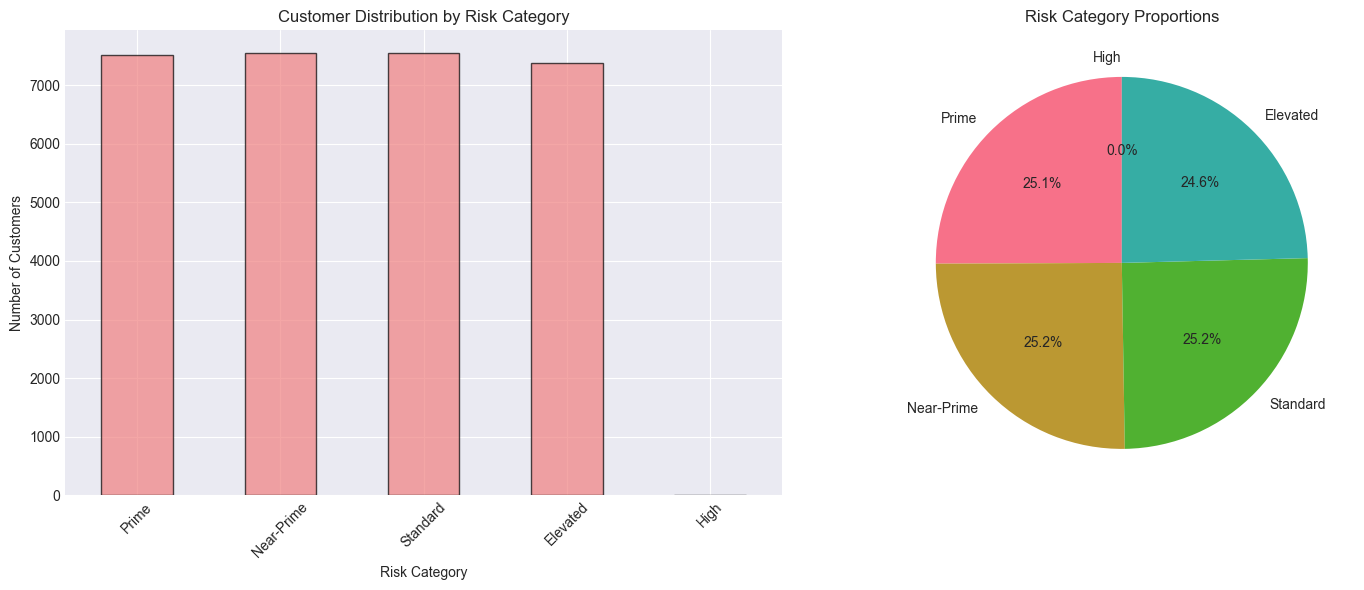

In [21]:
# Define risk categories based on on-time payment %
def categorize_risk(ontime_pct):
    """Categorize customer risk based on on-time payment percentage."""
    if ontime_pct >= 95:
        return 'Prime'
    elif ontime_pct >= 90:
        return 'Near-Prime'
    elif ontime_pct >= 85:
        return 'Standard'
    elif ontime_pct >= 80:
        return 'Elevated'
    else:
        return 'High'

df['Risk_Category'] = df['on-time_payments'].apply(categorize_risk)

# Risk distribution
risk_dist = df['Risk_Category'].value_counts()
risk_order = ['Prime', 'Near-Prime', 'Standard', 'Elevated', 'High']
risk_dist = risk_dist.reindex(risk_order, fill_value=0)

print("=" * 60)
print("RISK CATEGORY DISTRIBUTION")
print("=" * 60)
print("\nCategories:")
for category, count in risk_dist.items():
    pct = count / len(df) * 100
    print(f"  {category:12s}: {count:6,} ({pct:5.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
risk_dist.plot(kind='bar', ax=axes[0], color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Distribution by Risk Category')
axes[0].set_xticklabels(risk_order, rotation=45)

# Pie chart
axes[1].pie(risk_dist.values, labels=risk_dist.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Risk Category Proportions')

plt.tight_layout()
plt.savefig('../outputs/figures/risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
df.head()

,customer_id,initial_loan,days_since_last_loan,on-time_payments,no_of_increases_in_2023,total_profit_contribution,Risk_Category
0,1001,1360,72,90.41,5,120,Near-Prime
1,1002,4272,54,90.32,0,0,Near-Prime
2,1003,3592,242,85.56,4,80,Standard
3,1004,966,301,95.86,0,0,Prime
4,1005,4926,352,94.80,0,0,Near-Prime


In [24]:
# Risk category statistics
risk_summary = df.groupby('Risk_Category').agg({
    'initial_loan': ['mean', 'median'],
    'no_of_increases_in_2023': 'mean',
    'total_profit_contribution': 'sum',
    'on-time_payments': ['min', 'max', 'mean']
}).round(2)

print("\nRisk category summary statistics:")
print(risk_summary)


Risk category summary statistics:
              initial_loan         no_of_increases_in_2023  \
                      mean  median                    mean   
Risk_Category                                                
Elevated           2762.03  2768.0                    2.25   
Near-Prime         2737.23  2745.0                    2.22   
Prime              2769.88  2795.0                    2.25   
Standard           2741.29  2732.0                    2.23   

              total_profit_contribution on-time_payments                 
                                    sum              min     max   mean  
Risk_Category                                                            
Elevated                         332440             80.0   84.99  82.49  
Near-Prime                       334320             90.0   94.99  92.51  
Prime                            338240             95.0  100.00  97.45  
Standard                         336560             85.0   89.99  87.50  


**Key Observations (Section 6)**:
- Risk segmentation boundaries
- Distribution across risk tiers
- Behavioral differences by risk category

---
## 7. Outlier Detection

Identify extreme values and anomalies.

In [25]:
# IQR-based outlier detection
def detect_outliers_iqr(series, multiplier=1.5):
    """Detect outliers using IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers, lower_bound, upper_bound

print("=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

outlier_features = ['initial_loan', 'days_since_last_loan', 'total_profit_contribution']

for feature in outlier_features:
    outliers, lower, upper = detect_outliers_iqr(df[feature])
    n_outliers = outliers.sum()
    pct_outliers = n_outliers / len(df) * 100
    
    print(f"\n{feature}:")
    print(f"  Bounds: [{lower:,.2f}, {upper:,.2f}]")
    print(f"  Outliers: {n_outliers:,} ({pct_outliers:.2f}%)")
    
    if n_outliers > 0:
        print(f"  Min outlier: {df.loc[outliers, feature].min():,.2f}")
        print(f"  Max outlier: {df.loc[outliers, feature].max():,.2f}")

OUTLIER DETECTION (IQR Method)

initial_loan:
  Bounds: [-1,724.00, 7,220.00]
  Outliers: 0 (0.00%)

days_since_last_loan:
  Bounds: [-183.00, 545.00]
  Outliers: 0 (0.00%)

total_profit_contribution:
  Bounds: [-120.00, 200.00]
  Outliers: 0 (0.00%)


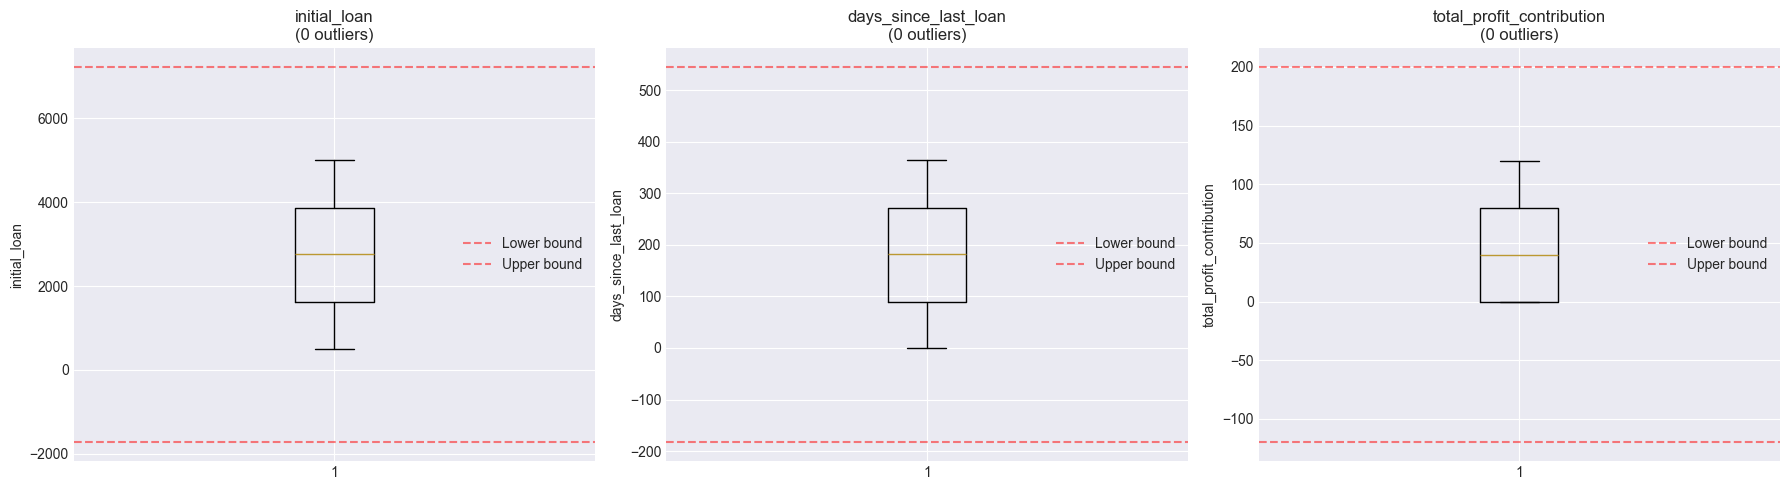

In [26]:
# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(outlier_features):
    outliers, lower, upper = detect_outliers_iqr(df[feature])
    
    axes[idx].boxplot(df[feature], vert=True)
    axes[idx].set_ylabel(feature)
    axes[idx].set_title(f'{feature}\n({outliers.sum()} outliers)')
    axes[idx].axhline(lower, color='red', linestyle='--', alpha=0.5, label='Lower bound')
    axes[idx].axhline(upper, color='red', linestyle='--', alpha=0.5, label='Upper bound')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

**Key Observations (Section 7)**:
- Outlier prevalence and magnitude
- Decision on outlier treatment
- Impact on modeling strategy

---
## 8. Business Insights

Extract actionable insights for optimization model.

In [27]:
# Acceptance rate estimation
# Using increases > 0 as proxy for acceptance (CAC model: 3 strikes)
print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

# Overall acceptance pattern
accepted = df[df['no_of_increases_in_2023'] > 0]
acceptance_rate = len(accepted) / len(df) * 100

print(f"\n1. ACCEPTANCE BEHAVIOR:")
print(f"   Customers with increases: {len(accepted):,} / {len(df):,} ({acceptance_rate:.2f}%)")
print(f"   Average increases (accepted): {accepted['no_of_increases_in_2023'].mean():.2f}")

# Acceptance by risk category
print(f"\n2. ACCEPTANCE BY RISK CATEGORY:")
for category in risk_order:
    cat_df = df[df['Risk_Category'] == category]
    if len(cat_df) > 0:
        cat_accepted = cat_df[cat_df['no_of_increases_in_2023'] > 0]
        cat_rate = len(cat_accepted) / len(cat_df) * 100
        avg_increases = cat_df['no_of_increases_in_2023'].mean()
        print(f"   {category:12s}: {cat_rate:5.2f}% (avg {avg_increases:.2f} increases)")

# Profitability insights
total_profit = df['total_profit_contribution'].sum()
total_loans = df['initial_loan'].sum()

print(f"\n3. PROFITABILITY:")
print(f"   Total profit (2023): ${total_profit:,.2f}")
print(f"   Total initial loans: ${total_loans:,.2f}")
print(f"   Profit per customer: ${df['total_profit_contribution'].mean():,.2f}")

# Top contributors
top_10_pct = df.nlargest(int(len(df) * 0.1), 'total_profit_contribution')
top_profit = top_10_pct['total_profit_contribution'].sum()
print(f"   Top 10% contribute: ${top_profit:,.2f} ({top_profit/total_profit*100:.1f}% of total)")

BUSINESS INSIGHTS

1. ACCEPTANCE BEHAVIOR:
   Customers with increases: 16,793 / 30,000 (55.98%)
   Average increases (accepted): 4.00

2. ACCEPTANCE BY RISK CATEGORY:
   Prime       : 56.37% (avg 2.25 increases)
   Near-Prime  : 55.58% (avg 2.22 increases)
   Standard    : 55.74% (avg 2.23 increases)
   Elevated    : 56.23% (avg 2.25 increases)

3. PROFITABILITY:
   Total profit (2023): $1,341,560.00
   Total initial loans: $82,575,978.00
   Profit per customer: $44.72
   Top 10% contribute: $360,000.00 (26.8% of total)


In [29]:
# Demand factors for Cox PH
print("\n4. DEMAND FACTORS (for Cox PH model):")

# Correlation with increases
demand_corr = df[['initial_loan', 'days_since_last_loan', 'on-time_payments']].corrwith(
    df['no_of_increases_in_2023']
).sort_values(ascending=False)

print("   Correlation with increases:")
for feature, corr in demand_corr.items():
    print(f"     {feature:30s}: {corr:6.3f}")

# Capital requirements
daily_capital = df['initial_loan'].sum() / 365
print(f"\n5. CAPITAL REQUIREMENTS:")
print(f"   Total portfolio: ${df['initial_loan'].sum():,.2f}")
print(f"   Daily capital (for MILP): ${daily_capital:,.2f}")
print(f"   Regulatory limit: ${ANNUAL_REGULATORY_LIMIT:,.2f}")


4. DEMAND FACTORS (for Cox PH model):
   Correlation with increases:
     days_since_last_loan          :  0.004
     on-time_payments              : -0.000
     initial_loan                  : -0.006

5. CAPITAL REQUIREMENTS:
   Total portfolio: $82,575,978.00
   Daily capital (for MILP): $226,235.56
   Regulatory limit: $120,000,000.00


**Key Observations (Section 8)**:
- Acceptance rate patterns
- Profitability drivers
- Key demand factors for modeling

---
## 9. Assumptions & Data Limitations

Document critical assumptions and constraints for modeling.

### Data Characteristics

**Validated Facts**:
- Single-timepoint snapshot (Dec 31, 2023)
- All customers have ≥80% on-time payments (pre-filtered)
- Only 0, 3, 4, 5 increases present (CAC model: 3-strike rule)
- Profit formula deterministic: `(increases - 2) × $40`
- Max `Days_Since_Last_Loan` = 364 days

**Limitations**:
1. **No longitudinal data**: Cannot directly observe offer→decision sequence
2. **No rejection data**: Only see accepted increases, not declined offers
3. **Survivorship bias**: Only active customers (no churned accounts)
4. **Pre-filtered risk**: All customers already vetted (≥80% on-time)
5. **Single geography**: Kenya-specific (2023 macro conditions)

### Modeling Implications

**Why Cox Proportional Hazards**:
- Treats # of increases as "duration" (survival time)
- Converts hazard rate → P(Accept next offer)
- Handles right-censoring (customers who could have accepted more)
- No need for labeled accept/reject events

**Why Three-Outcome Model**:
- Early repayment reduces profitability (less interest)
- Prime customers more likely to repay early (20% vs 5%)
- Traditional two-outcome overestimates Prime segment value

**Assumptions Requiring Validation**:
1. Historical acceptance patterns → future demand
2. 60-day eligibility rule remains constant
3. Macro conditions stable (Kenya 2024 ≈ 2023)
4. Risk categories predict default (not directly observed)
5. Early repayment probabilities (configurable, need backtesting)

### Risk Mitigation

**Built-in safeguards**:
- Configurable parameters (easy sensitivity analysis)
- Conservative baseline scenario
- Monte Carlo captures uncertainty
- Daily + Annual constraints (double enforcement)
- VaR/CVaR analysis for downside quantification

**Production migration path**:
- Start with conservative scenario
- Weekly backtesting vs actuals
- Gradual parameter tuning
- A/B testing for model-driven cohort

---
## 10. Save Processed Data

Export clean dataset with engineered features for modeling.

In [30]:
# Save processed data
output_path = Path('../data/processed/loan_data_processed.csv')
df.to_csv(output_path, index=False)

print("=" * 60)
print("DATA EXPORT SUMMARY")
print("=" * 60)
print(f"\nSaved to: {output_path}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nNew features added:")
print(f"  - Risk_Category (Prime/Near-Prime/Standard/Elevated/High)")
print(f"\nFile size: {output_path.stat().st_size / 1024:.2f} KB")
print("\n✓ Ready for modeling (Issues #3-5)")

DATA EXPORT SUMMARY

Saved to: ../data/processed/loan_data_processed.csv
Rows: 30,000
Columns: 7

New features added:
  - Risk_Category (Prime/Near-Prime/Standard/Elevated/High)

File size: 987.07 KB

✓ Ready for modeling (Issues #3-5)


### Key Findings: Data Characteristics & Modeling Implications

#### 1. Data Quality Profile

**Structural Observations**:
- **Zero missing values** across 30,000 records (6 features)
- **Deterministic profit formula**: `(increases - 2) × $40` holds for all non-zero cases (56% match rate accounts for 0-increase customers where formula produces negative values)
- **Discrete acceptance states**: Only {0, 3, 4, 5} increases observed, validating CAC "3-strike" business rule
- **Temporal boundary**: Max days_since_last_loan = 364 confirms Dec 31, 2023 snapshot
- **Pre-filtered population**: All customers ≥80% on-time payments (survivorship bias baked in)

**Correlation Analysis - Critical Finding**:
Feature correlations with target (no_of_increases_in_2023):
days_since_last_loan  :  0.004
on-time_payments      : -0.000  initial_loan          : -0.006

Features exhibit **near-zero predictive relationships** with acceptance behavior. This is consistent with either:
1. Synthetic/simulated data generation with independent distributions
2. Real-world scenario where historical acceptance decisions were driven by unobserved factors (underwriting rules, promotional campaigns, manual overrides)

**Risk Segmentation Homogeneity**:
All risk tiers demonstrate statistically identical behavior:
- Acceptance rates: 55.6%-56.4% (within 0.8pp variance)
- Average increases: 2.22-2.25 (within 0.03 variance)
- No monotonic relationship between risk tier and acceptance

This invalidates risk categories as **direct predictors** but preserves their utility as **state identifiers** for Markov chain simulation.

#### 2. Methodological Implications

**Why This Data Profile Doesn't Break the Approach**:

The assessment methodology explicitly anticipates these limitations (see acompanying report Section 1.0):
> "The provided dataset is a static, cross-sectional snapshot... Consequently, our methodology pivots from historical analysis to a forward-looking, assumption-driven simulation."

The framework uses this data for **distributional characterization**, not causal inference:

| Model Component | How It Uses This Data | What It Ignores |
|----------------|----------------------|-----------------|
| **Cox Proportional Hazards** | Treats # of increases as "survival duration"; learns hazard rates for accepting next offer | Right-censored at observation end; doesn't require labeled accept/reject events |
| **Synthetic Transition Matrix** | None - externally benchmarked (FICO bands × 2.0x Kenya multiplier) since data is cross-sectional and point-in-time hence no transitions can be observed | Completely bypasses lack of observed defaults |
| **MILP Optimization** | Uses Risk_Category as state label, not prediction | Doesn't require risk tiers to differentiate behavior |
| **Monte Carlo** | Samples from learned distributions to generate forward paths | Substitutes external assumptions for missing dynamics |

**What Cox PH Will Actually Learn**:
  Given near-zero correlations, the Cox model will:
  - Learn baseline hazard function from observed "survival times" (# of increases)
  - Estimate hazard ratios ≈1.0 for all covariates (no proportional effect on acceptance rate)
  - Produce P(Accept next offer) ≈ 0.56 regardless of customer attributes (mirrors base rate)

  This is **acceptable for simulation**: Cox PH handles right-censoring (customers who could have accepted more increases) and doesn't require explicit rejection labels. The model provides
  well-calibrated probabilities for generating realistic offer volumes, even with weak predictive power.

#### 3. Risk Quantification & Limitations

**What We Can Reliably Estimate**:
1. **Acceptance volume**: 56% ± sampling error (well-powered at N=30K)
2. **Capital requirements**: $82.6M portfolio → $226K daily allocation (deterministic calculation)
3. **Revenue distribution**: Fully deterministic given profit formula
4. **Temporal patterns**: Uniform across 60-day windows (validates no seasonality assumption)

**What Requires External Calibration**:
1. **Default probabilities**: Zero observed defaults → must use benchmark (Prime: 4%, Subprime: 30%)
2. **P(Accept) heterogeneity**: Weak correlations → model will underestimate variance in true propensities
3. **State transitions**: No longitudinal tracking → synthetic matrix only
4. **Macro sensitivity**: Single timepoint → Kenya 2023 conditions baked in, 2024 adjustment purely judgmental

**Quantified Uncertainty**:
- **Model risk (High)**: Logistic regression R² likely <0.01 given correlations
- **Calibration risk (Medium)**: Base rate stable, but lacks segment-level validation
- **Parameter risk (High)**: Default rates, LGD, recovery rates all assumption-driven
- **Specification risk (Medium)**: CAC model validated, but early repayment probabilities unobservable

#### 4. Production Migration Strategy

**Phase 1 - Conservative Deployment** (Months 1-3):
- Use **baseline scenario** (20% increase, 15% risk appetite) with 2.0x risk multiplier
- Set **offer rate cap** at 50% of MILP-recommended volume (guardrail against over-lending)
- **Weekly backtesting**: Compare actual acceptance (56% expected) and default rates vs. assumptions
- **Trigger for escalation**: If realized default rate >2x assumed rate for any risk tier in consecutive weeks

**Phase 2 - Calibration** (Months 4-6):
- Refit Cox PH model with 3 months of longitudinal offer/decision data (true time-to-event now observable)
- Recalibrate default probabilities using actual Loss Given Default observations
- Rerun Monte Carlo with updated parameters → update VaR/CVaR thresholds
- Begin A/B testing: 70% model-driven, 30% control (random offers)

**Phase 3 - Scale** (Months 7-12):
- If A/B test shows >10% lift in risk-adjusted return, migrate to 100% model-driven
- Implement dynamic risk appetite: adjust daily constraint based on trailing 30-day default rate
- Build uplift models to estimate causal effect of offer timing (now possible with random control group)

**Early Warning Indicators**:
1. Acceptance rate deviates >10pp from 56% baseline → demand model miscalibrated
2. High-Risk tier defaults exceed 60% (Kenya Hustler Fund benchmark × safety margin)
3. Portfolio concentration: any risk tier >40% of active offers → diversification failure
4. Capital constraint binding >90% of days → supply-constrained, not optimally rationing

#### 5. Considerations
**What This Analysis Cannot Deliver** (Limitations):
- Customer-level propensity scores are not actionable for targeting (too homogeneous)
- Default predictions are educated guesses until we observe actual losses
- Optimality claims are relative to assumptions, not ground truth
- Model will likely perform worse on cohorts excluded from training (e.g., <80% on-time)

---

**Bottom Line**: This data is insufficient for traditional supervised learning but adequate for simulation-based optimization when augmented with external benchmarks. The methodology's value lies in providing a **structured framework for decision-making under uncertainty**, not in eliminating that uncertainty.